# 07 · GSE65391 · RNA_array · heatmap, hierarchical clustering on both axes

Reads `modules.rds`, `wgcna_input.rds`, `metadata.rds`.

**Matrix.** The 157 first visits × the 10 hub genes (highest kME) of each module.

**Layout** (as in endotypes-proteomics): patients are rows, with their dendrogram and clinical
annotations on the left; genes are columns, with their dendrogram, names and WGCNA module colour on top.
Each gene is centred and scaled across patients (z-score); values are capped at ±2.5 for colour only.

**Clustering.** `hclust`, Ward's method (`ward.D2`) on Euclidean distance, applied separately to the
genes and to the patients.

**Test.** The patient dendrogram is cut into k groups. k is the value from 2 to 8 with the highest
mean silhouette width (Rousseeuw 1987) on the same Euclidean distance. The groups are compared with
each clinical trait: Kruskal–Wallis for numeric traits, Fisher's exact test for 0/1 traits; BH q across
traits. **A finding** is q < 0.05.

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize); library(cluster)})
mods <- readRDS(art("GSE65391", "modules.rds"))
w    <- readRDS(art("GSE65391", "wgcna_input.rds"))
m    <- readRDS(art("GSE65391", "metadata.rds"))[rownames(w$datExpr), ]
hub  <- unlist(lapply(mods$hubs, head, 10))
gene_module <- mods$colors[hub]
Z <- t(scale(w$datExpr[, hub]))                 # genes x patients, z-score per gene
dim(Z)

[1] 160 157

In [2]:
hc_genes    <- hclust(dist(Z), method = "ward.D2")
hc_patients <- hclust(dist(t(Z)), method = "ward.D2")
sil <- sapply(2:8, function(k) mean(silhouette(cutree(hc_patients, k), dist(t(Z)))[, "sil_width"]))
data.frame(k = 2:8, mean_silhouette = round(sil, 3))
K <- (2:8)[which.max(sil)]
patient_group <- factor(paste0("H", cutree(hc_patients, K)))
c(k = K); table(patient_group)

k,mean_silhouette
<int>,<dbl>
2,0.162
3,0.108
4,0.112
5,0.063
6,0.071
7,0.064
8,0.069


k 
2

patient_group
 H1  H2 
 46 111 

**Result.** k = 2 has the highest mean silhouette (0.162): groups of 46 and 111 children.

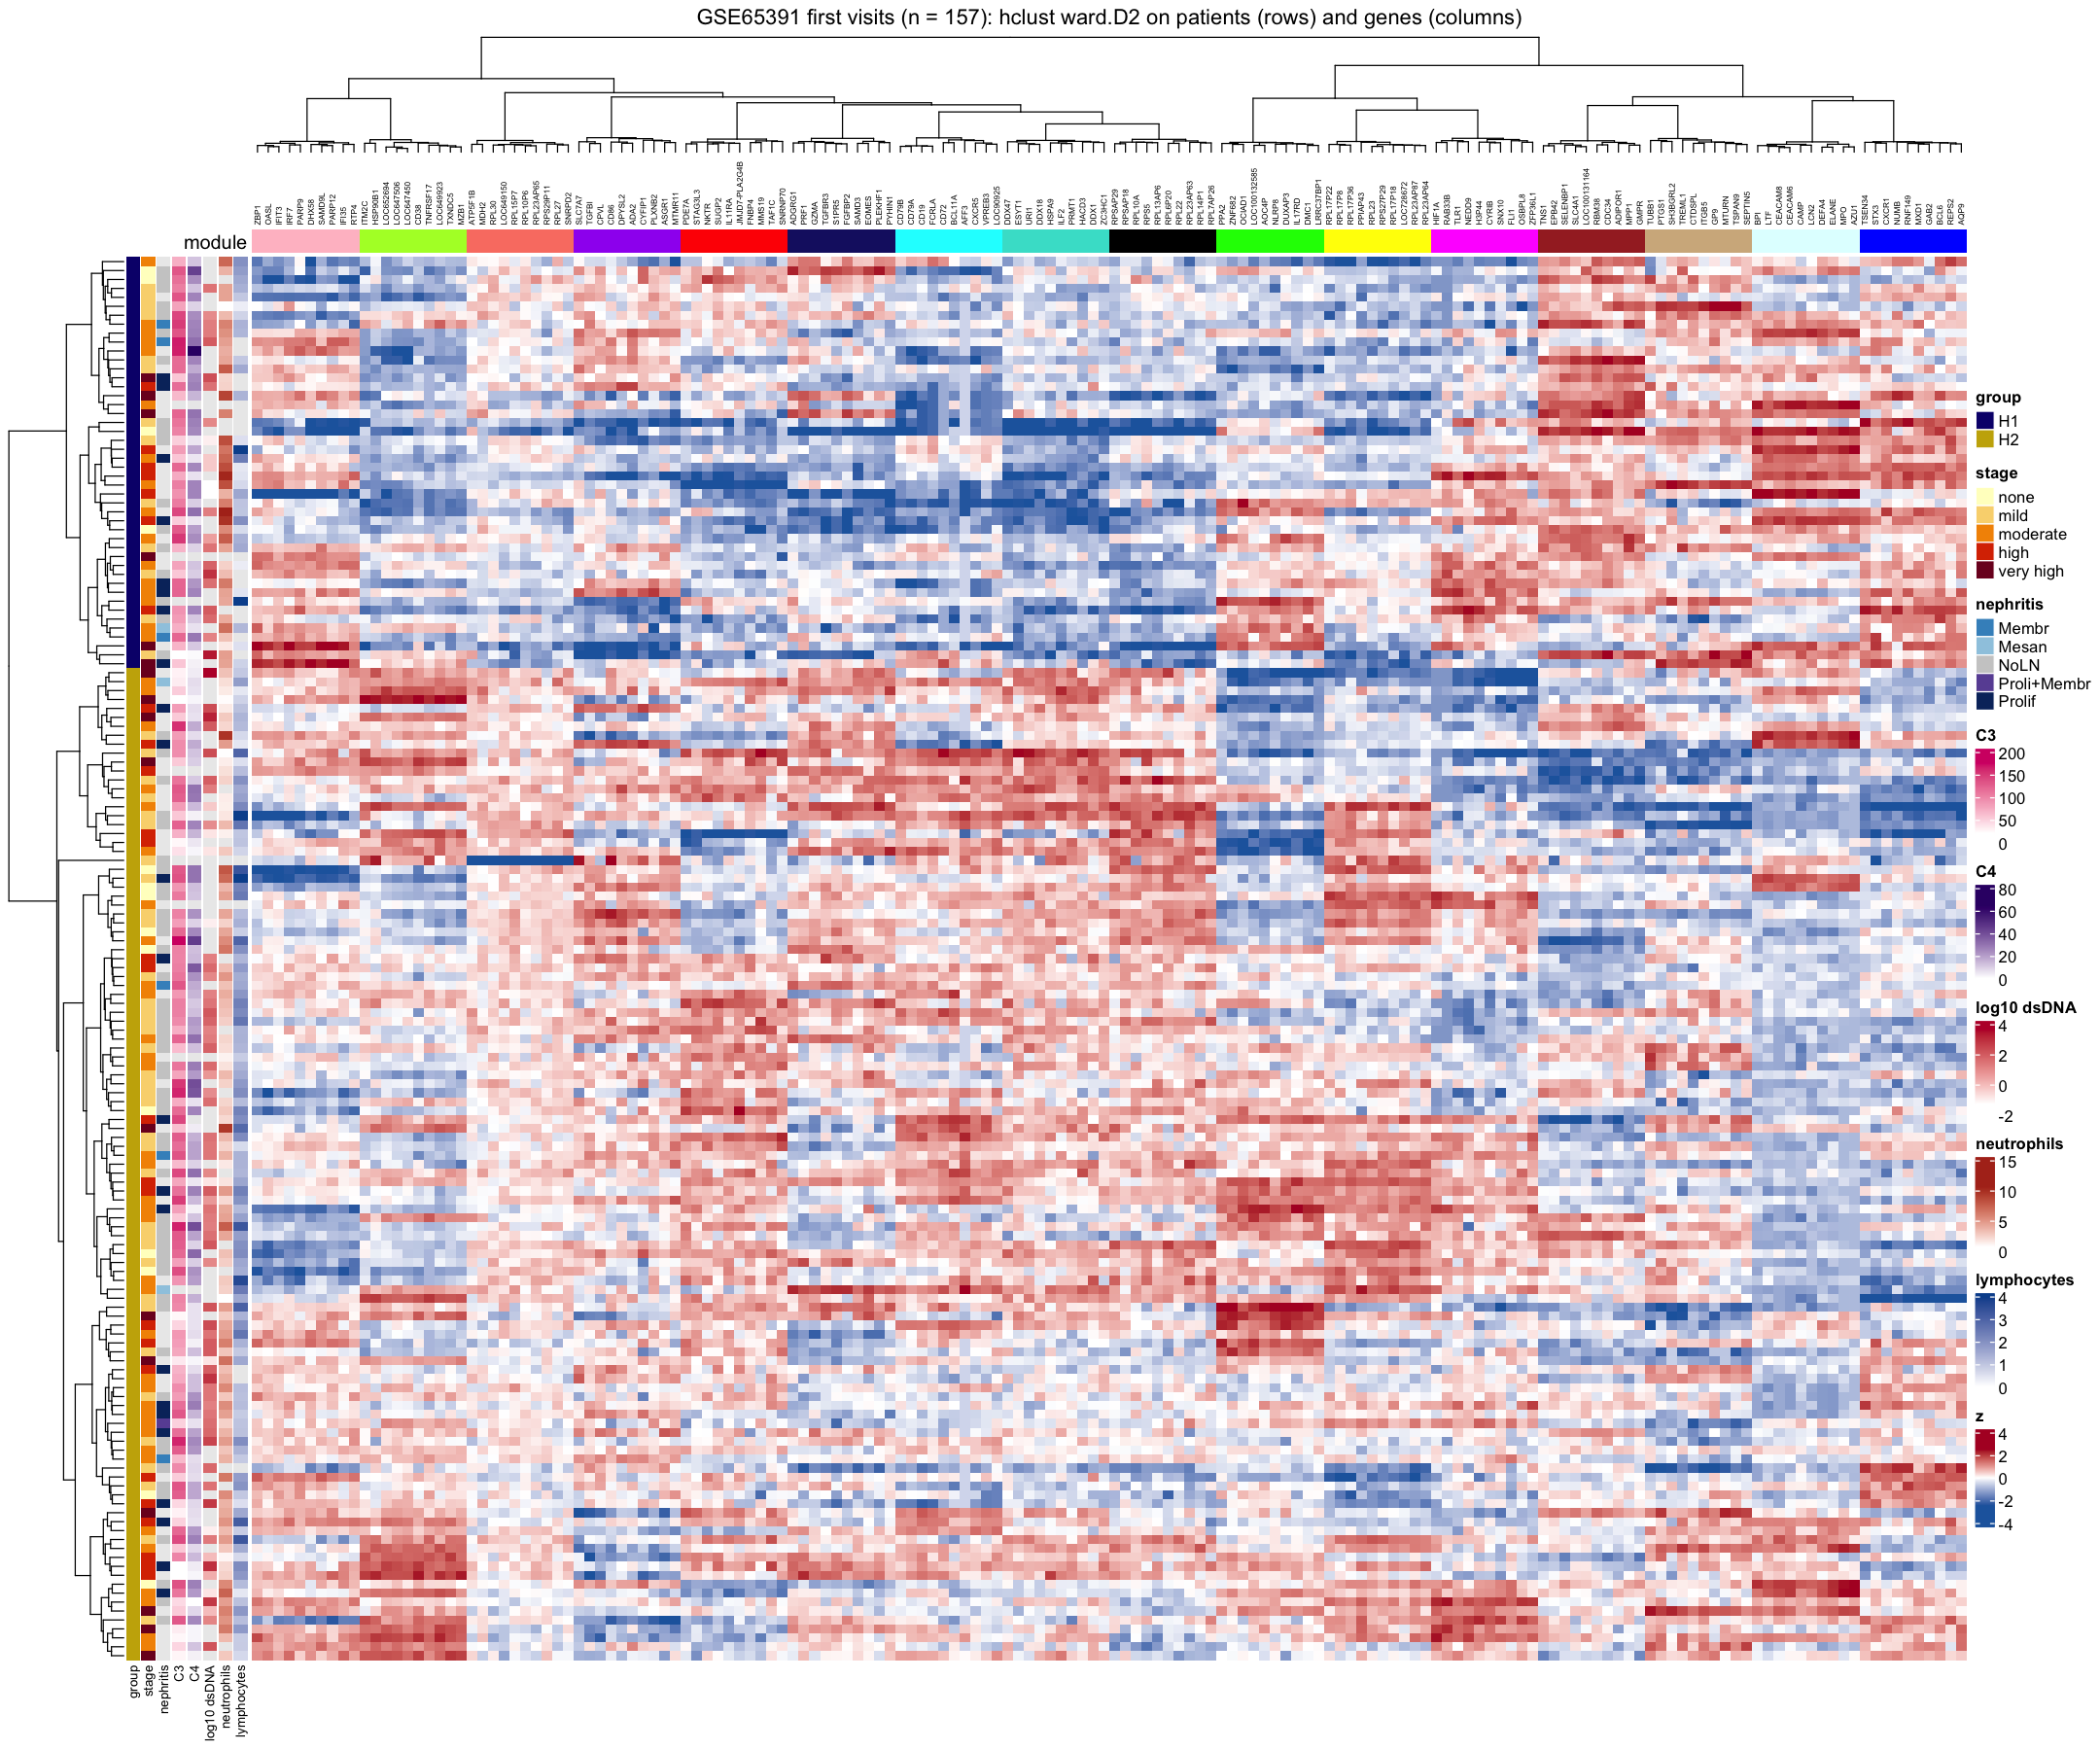

In [3]:
Zc <- pmin(pmax(Z, -2.5), 2.5)
mod_col <- setNames(unique(gene_module), unique(gene_module))       # WGCNA module names are colours
left <- rowAnnotation(
  group = patient_group, stage = m$stage, nephritis = m$nephritis_class,
  C3 = m$c3, C4 = m$c4, "log10 dsDNA" = log10(m$ds_dna),
  neutrophils = m$neutrophil_count, lymphocytes = m$lymphocyte_count, na_col = "grey92",
  # colour scale for lymphocytes capped at 4 (one child has 57.5, which would flatten the scale)
  col = list(stage = setNames(hcl.colors(5, "YlOrRd", rev = TRUE), levels(m$stage)),
             nephritis = c(NoLN = "grey80", Mesan = "#9ecae1", Membr = "#4292c6", Prolif = "#08306b", "Proli+Membr" = "#6a51a3"),
             lymphocytes = colorRamp2(c(0, 4), c("white", "#08519c"))),
  annotation_name_gp = gpar(fontsize = 8), simple_anno_size = unit(3, "mm"))
options(repr.plot.width = 18, repr.plot.height = 15)
Heatmap(t(Zc), name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
        cluster_rows = hc_patients, cluster_columns = hc_genes,
        row_dend_side = "left", column_dend_side = "top",
        row_dend_width = unit(25, "mm"), column_dend_height = unit(25, "mm"),
        show_row_names = FALSE, column_names_side = "top", column_names_gp = gpar(fontsize = 5),
        top_annotation = HeatmapAnnotation(module = gene_module, col = list(module = mod_col), show_legend = FALSE,
                                           annotation_name_side = "left"),
        left_annotation = left,
        column_title = sprintf("GSE65391 first visits (n = %d): hclust ward.D2 on patients (rows) and genes (columns)", ncol(Z)))

**Test result.** Patient groups (cut of the patient dendrogram) against each trait.

In [4]:
traits <- data.frame(sledai = m$sledai, stage = as.numeric(m$stage) - 1,
  nephritis_any = ifelse(is.na(m$nephritis_class), NA, as.numeric(m$nephritis_class != "NoLN")),
  nephritis_proliferative = ifelse(is.na(m$nephritis_class), NA, as.numeric(m$nephritis_class %in% c("Prolif", "Proli+Membr"))),
  age = m$age, female = as.numeric(m$sex == "F"), c3 = m$c3, c4 = m$c4, ds_dna_log10 = log10(m$ds_dna),
  wbc = m$wbc, neutrophil_count = m$neutrophil_count, lymphocyte_count = m$lymphocyte_count, platelet_count = m$platelet_count,
  oral_steroids = m$oral_steroids, iv_steroids = m$iv_steroids, mycophenolate = m$mycophenolate,
  hydroxychloroquine = m$hydroxychloroquine, cyclophosphamide = m$cyclophosphamide)
group_tests <- function(g) {
  out <- do.call(rbind, lapply(names(traits), function(tr) {
    v <- traits[[tr]]; ok <- !is.na(v)
    binary <- all(v %in% c(0, 1, NA))
    p <- if (binary) fisher.test(table(g[ok], v[ok]))$p.value else kruskal.test(v[ok], g[ok])$p.value
    data.frame(trait = tr, test = if (binary) "Fisher" else "Kruskal-Wallis", n = sum(ok), p = p)
  }))
  out$q <- p.adjust(out$p, "BH"); out[order(out$p), ]
}
hc_tests <- group_tests(patient_group)
hc_tests

,trait,test,n,p,q
,<chr>,<chr>,<int>,<dbl>,<dbl>
11,neutrophil_count,Kruskal-Wallis,138,3.743237e-05,0.0006737827
10,wbc,Kruskal-Wallis,143,1.436821e-04,0.0012931390
12,lymphocyte_count,Kruskal-Wallis,137,1.088016e-02,0.0652809687
14,oral_steroids,Fisher,157,2.088270e-02,0.0765042984
18,cyclophosphamide,Fisher,156,2.160526e-02,0.0765042984
8,c4,Kruskal-Wallis,148,2.550143e-02,0.0765042984
5,age,Kruskal-Wallis,157,3.724611e-02,0.0869075454
16,mycophenolate,Fisher,157,3.862558e-02,0.0869075454
15,iv_steroids,Fisher,157,6.478109e-02,0.1295621760


**Result.** The two hierarchical groups differ in neutrophil count (q = 0.0007) and white cell count
(q = 0.001). No other trait reaches q < 0.05; SLEDAI, stage and nephritis do not.